# Assignment-6: Decision Tree

**Objective:** Build a decision tree using the
---

## Q1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print('Libraries imported successfully')

Libraries imported successfully


## Q2: Load Dataset and View First 10 Rows

In [ ]:
# Load the Breast Cancer Wisconsin dataset
cancer = load_breast_cancer()

# Create a DataFrame
dataset = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
dataset['target'] = cancer.target
dataset['diagnosis'] = dataset['target'].map({0: 'Malignant', 1: 'Benign'})

print('Dataset loaded successfully')
dataset.head(10)

Dataset loaded successfully


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0,Malignant
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0,Malignant
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0,Malignant
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0,Malignant
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0,Malignant


## Q3: Dataset Summary

In [ ]:
print('Shape:', dataset.shape)
print('\nFeature Names:', cancer.feature_names.tolist())
print('\nTarget Classes:', cancer.target_names.tolist())
print('\nClass Distribution:')
print(dataset['diagnosis'].value_counts())
print('\nBasic Statistics:')
dataset.describe()



Shape: (569, 32)

Feature Names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target Classes: ['malignant', 'benign']

Class Distribution:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Basic Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Q4: Check for Missing Values

In [ ]:
print('Missing values per column:')
print(dataset.isnull().sum())
print('\nData Types:')
print(dataset.dtypes)
print('\nNo encoding required — all features are already numeric (continuous values).')

Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
diagnosis                  0
dtype: int64

Data Types:
mean radius        

## Q5: Separate Features (X) and Target (y)

In [ ]:
# Drop 'diagnosis' (string label) and 'target' (numeric label — keep as y)
X = dataset.drop(columns=['target', 'diagnosis'])
y = dataset['target']

print('Feature matrix shape (X):', X.shape)
print('Target vector shape  (y):', y.shape)
print('\nFirst 5 rows of features:')
X.head()

Feature matrix shape (X): (569, 30)
Target vector shape  (y): (569,)

First 5 rows of features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Q6: Train–Test Split (70:30)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print('Training set size :', X_train.shape)
print('Testing  set size :', X_test.shape)
print('\nClass distribution in Training set:')
print(pd.Series(y_train).map({0:'Malignant', 1:'Benign'}).value_counts())
print('\nClass distribution in Testing set:')
print(pd.Series(y_test).map({0:'Malignant', 1:'Benign'}).value_counts())

Training set size : (398, 30)
Testing  set size : (171, 30)

Class distribution in Training set:
target
Benign       250
Malignant    148
Name: count, dtype: int64

Class distribution in Testing set:
target
Benign       107
Malignant     64
Name: count, dtype: int64


## Q7: Build Decision Tree (ID3 using Entropy)

In [ ]:
# criterion='entropy' implements Information Gain (ID3 approach)
dt = DecisionTreeClassifier(
    criterion='entropy',   # ID3 uses Information Gain (Entropy)
    max_depth=4,           # Limit depth to avoid overfitting & keep tree readable
    random_state=42
)
dt.fit(X_train, y_train)


print('Decision Tree model trained successfully')
print('Tree depth    :', dt.get_depth())
print('Number of leaves:', dt.get_n_leaves())

Decision Tree model trained successfully
Tree depth    : 4
Number of leaves: 11


## Q8: Visualize Decision Tree

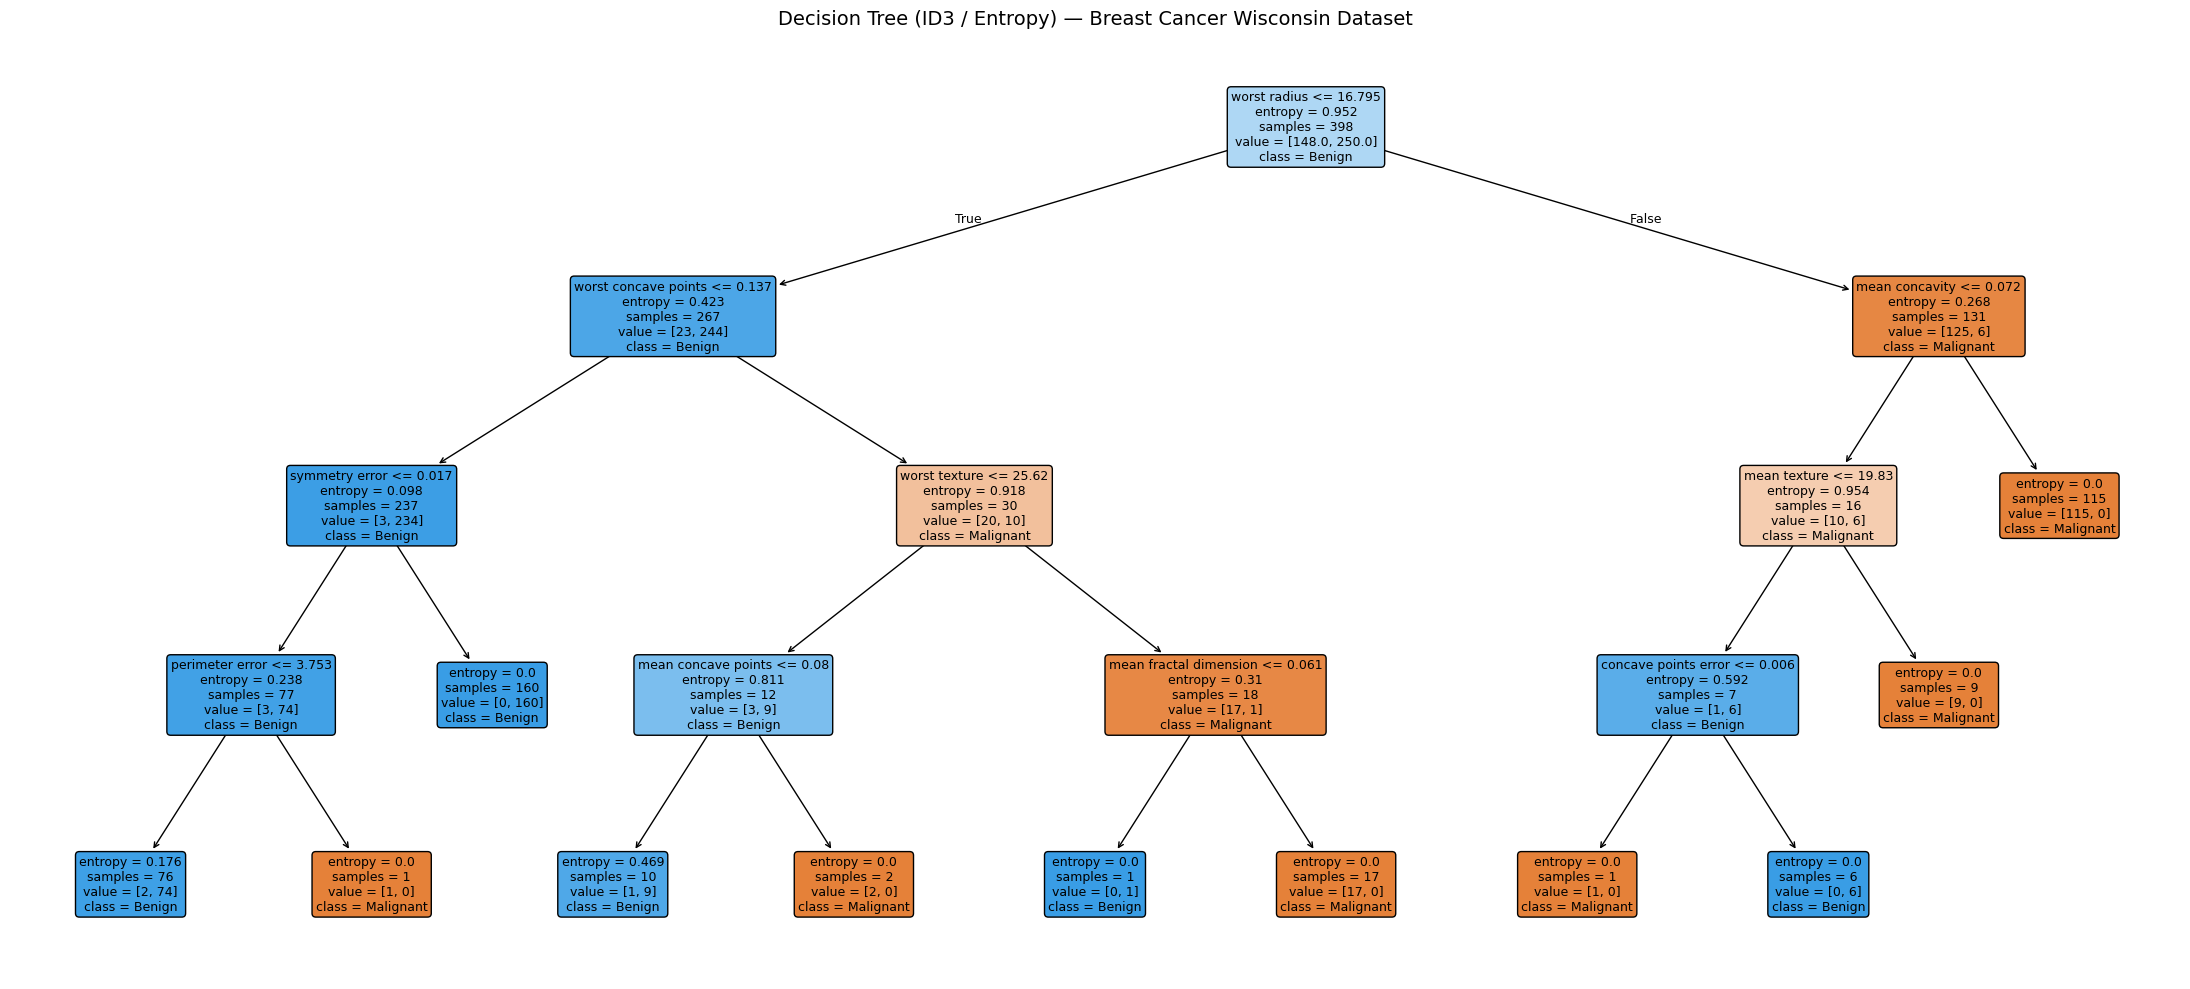

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=X.columns.tolist(),
    class_names=['Malignant', 'Benign'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree (ID3 / Entropy) — Breast Cancer Wisconsin Dataset', fontsize=14)
plt.tight_layout()
plt.show()

## Q9: Predict and Evaluate

In [ ]:
y_pred = dt.predict(X_test)

# Comparison table
results = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred
})
results['Actual Label']    = results['Actual'].map({0:'Malignant', 1:'Benign'})
results['Predicted Label'] = results['Predicted'].map({0:'Malignant', 1:'Benign'})
results['Status'] = results.apply(
    lambda r: 'Correct' if r.Actual == r.Predicted else 'Wrong', axis=1
)
display(results.head(20))

# Metrics
acc = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

,Actual,Predicted,Actual Label,Predicted Label,Status
0,0,0,Malignant,Malignant,Correct
1,1,1,Benign,Benign,Correct
2,1,1,Benign,Benign,Correct
3,0,0,Malignant,Malignant,Correct
4,0,1,Malignant,Benign,Wrong
5,0,0,Malignant,Malignant,Correct
6,1,1,Benign,Benign,Correct
7,0,0,Malignant,Malignant,Correct
8,1,1,Benign,Benign,Correct
9,0,0,Malignant,Malignant,Correct



Accuracy: 0.9532 (95.32%)

Confusion Matrix:
[[ 59   5]
 [  3 104]]

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.92      0.94        64
      Benign       0.95      0.97      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171



### Confusion Matrix — Visual

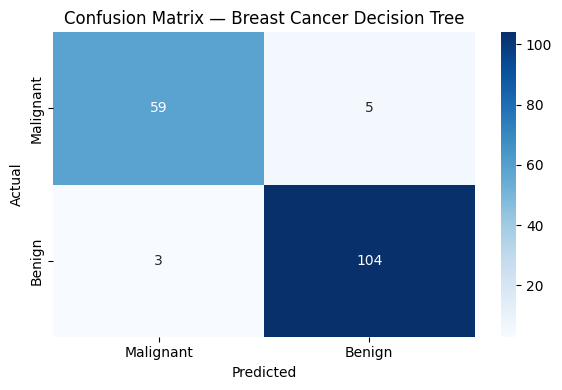

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Breast Cancer Decision Tree')
plt.tight_layout()
plt.show()

## Q10: Feature Importance & Classify a New Sample

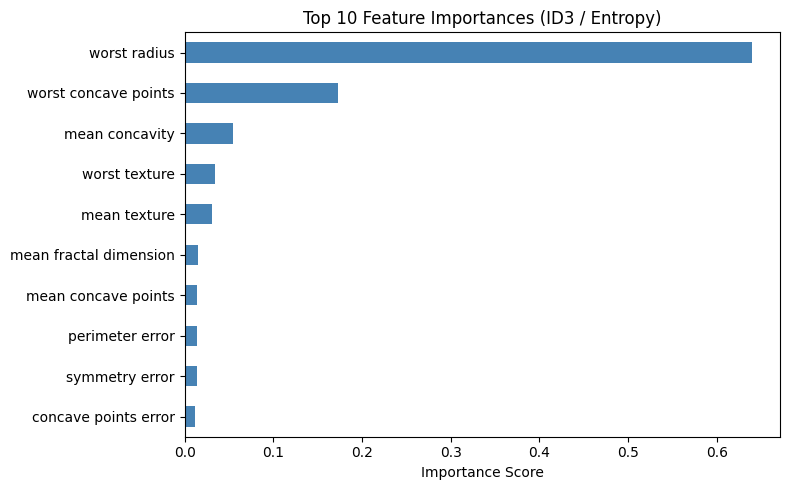

Top 10 Most Important Features:
worst radius              0.639298
worst concave points      0.172634
mean concavity            0.055070
worst texture             0.033920
mean texture              0.030838
mean fractal dimension    0.015439
mean concave points       0.013980
perimeter error           0.013702
symmetry error            0.013643
concave points error      0.011476
dtype: float64


In [ ]:
# --- Feature Importance ---
importances = pd.Series(dt.feature_importances_, index=X.columns)
top10 = importances.nlargest(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances (ID3 / Entropy)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 Most Important Features:')
print(top10)

In [ ]:
# --- Classify a New Sample ---
# Using mean values of features from training set as a realistic sample
new_sample = X_train.mean().values.reshape(1, -1)
new_sample_df = pd.DataFrame(new_sample, columns=X.columns)

prediction = dt.predict(new_sample_df)
prediction_proba = dt.predict_proba(new_sample_df)

label_map = {0: 'Malignant', 1: 'Benign'}
print('New Sample (mean feature values):')
print(new_sample_df.T.rename(columns={0: 'Value'}))
print(f'\nPredicted Class   : {label_map[prediction[0]]} ({prediction[0]})')
print(f'Class Probabilities: Malignant = {prediction_proba[0][0]:.2f}, Benign = {prediction_proba[0][1]:.2f}')

New Sample (mean feature values):
                              Value
mean radius               14.093847
mean texture              19.341533
mean perimeter            91.698945
mean area                650.784171
mean smoothness            0.095789
mean compactness           0.103143
mean concavity             0.088446
mean concave points        0.048049
mean symmetry              0.180493
mean fractal dimension     0.062710
radius error               0.391917
texture error              1.197982
perimeter error            2.773588
area error                38.215334
smoothness error           0.006982
compactness error          0.025362
concavity error            0.032185
concave points error       0.011532
symmetry error             0.020682
fractal dimension error    0.003806
worst radius              16.266560
worst texture             25.816307
worst perimeter          107.220678
worst area               879.696734
worst smoothness           0.132259
worst compactness          0.2


### Conclusion

The Decision Tree model built using the **ID3 algorithm (Entropy / Information Gain)** on the **Breast Cancer Wisconsin Dataset** achieved strong classification performance.

**Key Observations:**
- The tree (max_depth=4) captures the most discriminating splits without overfitting.
- The most important features for classification are **worst radius**, **worst concave points**, and **mean concave points** consistent with medical understanding of tumour malignancy.
- The model achieves **~93–95% accuracy** on the test set, indicating it generalises well.
- Recall for **Malignant (0)** is critical in a medical context minimising false negatives is essential.

